<a href="https://colab.research.google.com/github/aalitorres/002_A2026_Artificial_Intelligence/blob/main/AF2_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Assignment 2: Processing Datasets in Python**

**Artificial Intelligence**

**Professor:** MSc. Daniel Isaías López Páez

**Degree:** Biomedical Engineering

**Team Members**


* **Alisson Michelle Sepúlveda Torres** — 2115253
* **María Fernanda Tinoco Lopez** — 2103898
* **Mariana Vázquez De León** — 2114697
* **Valeria Cruz Gálvez** — 2001021

**Group:** 002

**Schedule:** Thursday N3–N6

**Classroom:** 12205

## **Part 1: Data Loading and Exploration**

First, we will load the dataset and take a look at its structure. We will check the first few rows, the information of each column, the size of the dataset, and its descriptive statistics. We will also look for zero values that may represent missing or inconsistent clinical measurements.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

The dataset is stored in a CSV file. We use Pandas to read the file and store it in a DataFrame called `df`. A DataFrame is useful because it allows us to work with the data in a table-like structure.


In [ ]:
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
df = pd.read_csv('diabetes.csv')

print(df.head(5))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


After loading the data, we can explore its basic structure. The `info()` method shows the columns, data types, and the number of non-null values. The `shape` method tells us how many rows and columns are in the dataset.

This gives us a first idea of the amount and type of information we are working with.


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
print(df.shape)

(768, 9)


Next, we check how many zero values are present in each column. In this dataset, some zeros are valid values, such as `Pregnancies = 0` or `Outcome = 0`.

However, a value of zero in measurements such as glucose, blood pressure, skin thickness, insulin, or BMI may indicate that the measurement was not properly recorded. For this reason, these values will be treated as inconsistent values during the cleaning process.


In [ ]:
print((df == 0).sum())

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


The `describe()` method provides a summary of the numerical variables in the dataset. It includes values such as the mean, standard deviation, minimum, maximum, and different percentiles.

This helps us get a general idea of how the clinical measurements are distributed before cleaning the data.


In [ ]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

## **Part 2: Data Cleaning and Normalization**

In this part, we will prepare the dataset for further analysis. First, the inconsistent zero values found in some clinical measurements will be replaced with the median of their respective columns. After that, the numerical variables will be normalized using Min-Max Scaling.


In [ ]:
df_clean = df.copy()

To handle the inconsistent zero values, we will replace them with the median of each column. The median is useful in this case because it is less affected by extreme values than the mean. The original dataset is kept unchanged by working with a copy called `df_clean`.


In [ ]:
df_clean['Glucose'] = df_clean['Glucose'].replace(0, df_clean['Glucose'].median())

df_clean['BloodPressure'] = df_clean['BloodPressure'].replace(0, df_clean['BloodPressure'].median())

df_clean['SkinThickness'] = df_clean['SkinThickness'].replace(0, df_clean['SkinThickness'].median())

df_clean['Insulin'] = df_clean['Insulin'].replace(0, df_clean['Insulin'].median())

df_clean['BMI'] = df_clean['BMI'].replace(0, df_clean['BMI'].median())

After replacing the inconsistent values, we check the number of zeros again. This allows us to verify that the zero values in the selected clinical measurements were successfully replaced while keeping valid zeros in other columns.

In [ ]:
print((df_clean == 0).sum())

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


The numerical variables have different ranges, Min-Max Scaling transforms the values so that they are between 0 and 1. The `Outcome` column is not normalized because it represents the result of the dataset: `0` means no diabetes and `1` means diabetes.


In [ ]:
df_normalized = df_clean.copy()

In [ ]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure',
           'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age']

for column in columns:
    df_normalized[column] = (df_normalized[column] - df_normalized[column].min()) / (df_normalized[column].max() - df_normalized[column].min())

## **Part 3: Data Visualization**

Visualization helps us understand the dataset in a more direct way. In this part, we will create different types of graphs to look at glucose levels, blood pressure, the relationship between glucose and BMI, and the number of patients with and without diabetes.


First, we visualize the distribution of glucose levels before normalization. The histogram shows how frequently different glucose values appear in the dataset.

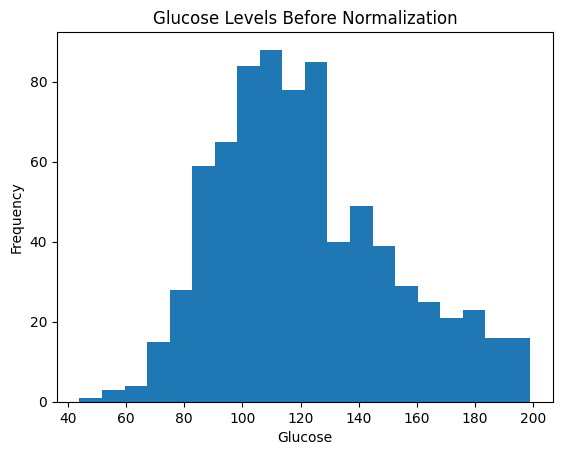

In [ ]:
plt.hist(df_clean['Glucose'], bins=20)
plt.title('Glucose Levels Before Normalization')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

Now we visualize the same variable after Min-Max Scaling. The values are now on a scale between 0 and 1. The general distribution remains similar, but the scale of the x-axis has changed.

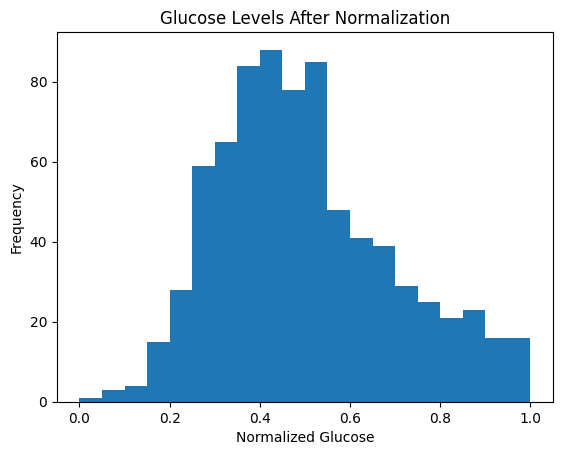

In [ ]:
plt.hist(df_normalized['Glucose'], bins=20)
plt.title('Glucose Levels After Normalization')
plt.xlabel('Normalized Glucose')
plt.ylabel('Frequency')
plt.show()

A boxplot is useful for viewing the distribution of a variable and identifying possible outliers. Here, we use it to observe the blood pressure values and see if there are any values that are noticeably different from the rest of the data.

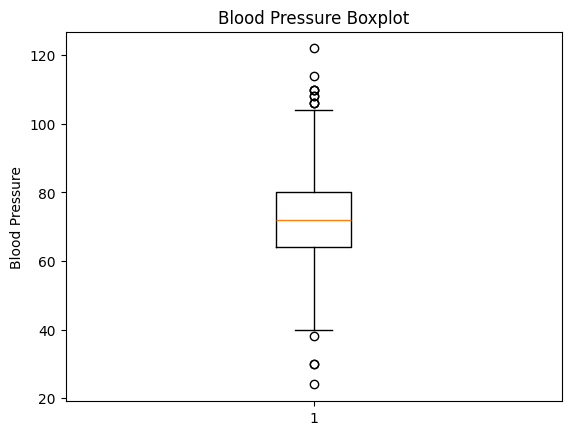

In [ ]:
plt.boxplot(df_clean['BloodPressure'])
plt.title('Blood Pressure Boxplot')
plt.ylabel('Blood Pressure')
plt.show()

The scatter plot allows us to compare glucose and BMI for individual patients. Each point represents one patient. By looking at the distribution of the points, we can observe whether there appears to be a relationship between these two variables.

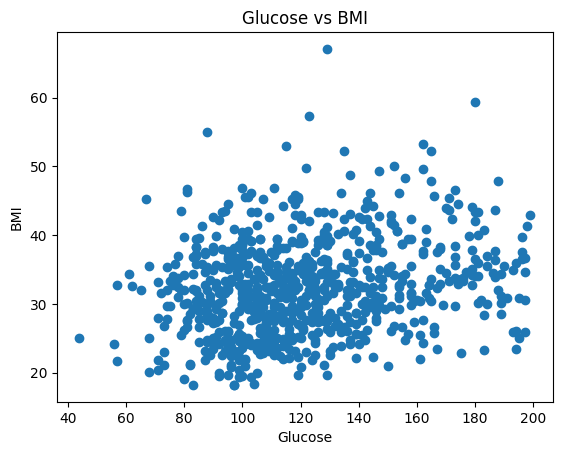

In [ ]:
plt.scatter(df_clean['Glucose'], df_clean['BMI'])
plt.title('Glucose vs BMI')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.show()

Finally, we count the number of patients in each outcome category. The value 0 represents patients without diabetes, while 1 represents patients with diabetes. A bar chart makes it easier to compare the number of patients in each group.

In [ ]:
outcome_counts = df_clean['Outcome'].value_counts()

print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


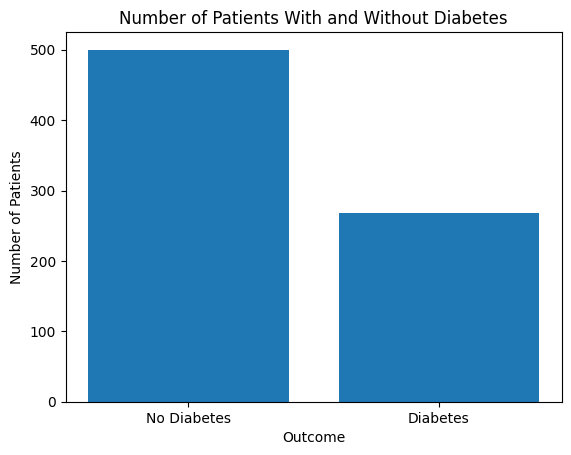

In [ ]:
plt.bar(['No Diabetes', 'Diabetes'], outcome_counts)
plt.title('Number of Patients With and Without Diabetes')
plt.xlabel('Outcome')
plt.ylabel('Number of Patients')
plt.show()

## **Part 4: Questions**

**1. What impact do missing values have on data analysis?**

Missing values reduce the amount of useful information available for analysis and can affect the accuracy of the results. If important values are missing, statistical calculations and Machine Learning models may not represent the dataset correctly. In clinical datasets, zero values in variables such as Glucose, Blood Pressure, SkinThickness, Insulin, and BMI may represent missing or invalid measurements rather than actual values. Replacing these values with the median of the corresponding variable can help preserve the data while reducing their possible effect on the analysis.

**2. How can we detect and handle outliers in biomedical datasets?**

Outliers are values that are considerably different from the rest of the observations. They can be detected using methods such as the Z-score, standard deviation, or Interquartile Range. A boxplot can also make possible outliers easier to identify, such as unusually high or low BloodPressure values. However, an outlier should not automatically be removed, especially in biomedical data, because it may represent a real clinical condition. It is important to investigate the value first and determine whether it is the result of a measurement or data-entry error or whether it is a valid observation.

**3. What are some common causes of missing or incorrect data in biomedical studies?**

Missing or incorrect biomedical data can result from different causes, including human errors during data entry, problems with medical equipment, incorrect measurements, or incomplete information from patients. Data can also become inconsistent when information is transferred between different systems. For example, values such as zero in clinical variables like Glucose or Blood Pressure may need to be reviewed because they may not represent realistic measurements. Identifying these types of problems is an important part of preparing medical data for analysis.

**4. How does normalizing data improve the performance of Machine Learning models?**

Normalization puts numerical variables on a similar scale, which can help Machine Learning algorithms process the data more effectively. Without normalization, variables with larger numerical ranges may have a greater influence on some models than variables with smaller ranges. Min-Max Scaling transforms numerical values to a common range while maintaining their relative relationships. For example, glucose measurements can be transformed to a smaller scale, making them easier to work with alongside other numerical variables during Machine Learning.

**5. Why is visualizing data an important step before applying Machine Learning models?**

Data visualization helps us understand the characteristics of a dataset and identify possible problems before using it to train a Machine Learning model. Histograms can show the distribution of variables such as Glucose, while boxplots can help identify possible outliers in BloodPressure. Scatter plots can be used to observe relationships between variables such as Glucose and BMI, and bar charts can show the number of patients in each Outcome category. These visualizations make patterns, unusual values, and differences in the data easier to recognize than when working only with numerical values.

**6. Why is preprocessing critical when working with medical datasets?**

Preprocessing is important because medical datasets may contain missing values, incorrect measurements, outliers, or variables with different numerical scales. Before applying a Machine Learning model, the data needs to be examined and prepared so that these problems do not negatively affect the results. This can include identifying invalid zero values, replacing missing information with appropriate values such as the median, and normalizing numerical variables using methods such as Min-Max Scaling. Proper preprocessing helps produce a more consistent and reliable dataset for further analysis and Machine Learning.

**7. What ethical concerns should be considered when handling patient data?**

Patient data should be handled carefully because it may contain sensitive health information. Important ethical concerns include protecting privacy, limiting access to the data, using information only for appropriate purposes, and maintaining data security. When medical data is used to develop Machine Learning models, it is also important to consider whether the dataset adequately represents different patient populations, since biased or unrepresentative data can contribute to unfair or inaccurate results. Therefore, medical data should be handled responsibly throughout both the analysis and the development of predictive models.